<a href="https://www.kaggle.com/code/parask29/uber-ride-cancellation?scriptVersionId=308192792" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/parask29/uber-dataset/uber-data.csv


# **## Uber is facing ride cancellations by driver for specific route.**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/parask29/uber-dataset/uber-data.csv', na_values = 'NA', parse_dates = [4,5], dayfirst = True)

In [3]:
df.head()


,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/7/2016 11:51,11/7/2016 13:00
1,867,Airport,1.0,Trip Completed,11/7/2016 17:57,11/7/2016 18:47
2,1807,City,1.0,Trip Completed,12/7/2016 9:17,12/7/2016 9:58
3,2532,Airport,1.0,Trip Completed,12/7/2016 21:08,12/7/2016 22:03
4,3112,City,1.0,Trip Completed,13-07-2016 08:33:16,13-07-2016 09:25:47


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


In [5]:
#df['Status'].size()

In [6]:
df.isna().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

In [7]:
df = df.fillna('NA')

In [8]:
df.isna().sum()

Request id           0
Pickup point         0
Driver id            0
Status               0
Request timestamp    0
Drop timestamp       0
dtype: int64

In [9]:
df.shape

(6745, 6)

In [10]:
print('No of rows : {}'.format(df.shape[0]))
print('No of columns : {}'.format(df.shape[1]))

No of rows : 6745
No of columns : 6


In [11]:
df.duplicated().sum()

np.int64(0)

# Feature Extraction

In [12]:
# Convert column to dateTime
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], errors = 'coerce')
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'], errors = 'coerce')


In [13]:
# Extract hour and create new col: 
df['Request Hour'] = df['Request timestamp'].dt.hour

In [14]:
# Create TimeSlot Categorical feature
df['TimeSlot'] = df['Request Hour'].apply(lambda x: 'Dawn' if x<4 else ( 'Early Morning' if x>=4 and x<9 else('Noon'if x>=9 and x<16 else('Late Evening' if x>=16 and x<20 else 'Night'))))

# Alternate method :  Cut Method

'''
times = [0,4,9,16,20,24]
cate_val = ['Dawn', 'Early Morning', 'Noon', 'Late Evening', "Night"]
df['TimeSlot'] = pd.cut(x = df['Request Hour'], bins = 'times', labels = 'cate_val')

'''

'\ntimes = [0,4,9,16,20,24]\ncate_val = [\'Dawn\', \'Early Morning\', \'Noon\', \'Late Evening\', "Night"]\ndf[\'TimeSlot\'] = pd.cut(x = df[\'Request Hour\'], bins = \'times\', labels = \'cate_val\')\n\n'

In [15]:
df['Status'].value_counts()

Status
Trip Completed       2831
No Cars Available    2650
Cancelled            1264
Name: count, dtype: int64

In [16]:
df['Cab availabilty'] = df['Status'].apply(lambda x : 'Available' if x == 'Trip Completed' else 'Not Available')

In [17]:
df['Cab availabilty'].value_counts()

# Percentage :
df['Cab availabilty'].value_counts(1)*100



Cab availabilty
Not Available    58.028169
Available        41.971831
Name: proportion, dtype: float64

In [18]:
hour_CabAvai = df.groupby(['Request Hour', 'Cab availabilty']).size()

In [19]:
hour_CabAvai.head()

Request Hour  Cab availabilty
0.0           Available          13
              Not Available      19
1.0           Available           8
              Not Available      20
2.0           Available           7
dtype: int64

In [20]:
TimeSlot_CabAvai = df.groupby(['TimeSlot', 'Cab availabilty'])
TimeSlot_CabAvai

In [21]:
TimeSlot_CabAvai = df.groupby(['TimeSlot', 'Cab availabilty']).size()
TimeSlot_CabAvai

TimeSlot       Cab availabilty
Dawn           Available            40
               Not Available        81
Early Morning  Available           312
               Not Available       421
Late Evening   Available           236
               Not Available       401
Night          Available          1885
               Not Available      2741
Noon           Available           358
               Not Available       270
dtype: int64

In [22]:
TimeSlot_CabAvai = df.groupby(['TimeSlot', 'Cab availabilty']).size().unstack()
TimeSlot_CabAvai

Cab availabilty,Available,Not Available
TimeSlot,,
Dawn,40,81
Early Morning,312,421
Late Evening,236,401
Night,1885,2741
Noon,358,270


<Axes: xlabel='TimeSlot'>

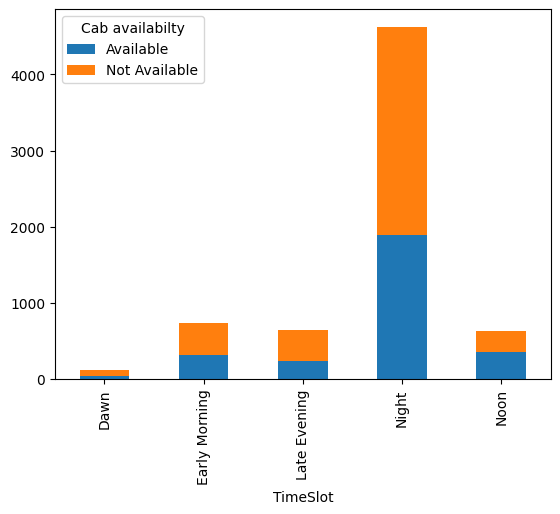

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
df.groupby(['TimeSlot', 'Cab availabilty']).size().unstack().plot(kind = 'bar', stacked = True)

<Axes: >

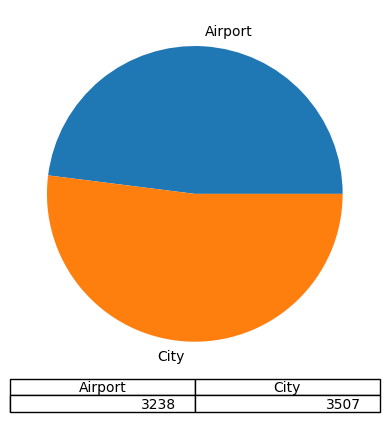

In [24]:
df.groupby(['Pickup point']).size().plot(kind = 'pie', table = True)

In [25]:
df[df['Cab availabilty'] == 'Available'].groupby(['TimeSlot']).size()

TimeSlot
Dawn               40
Early Morning     312
Late Evening      236
Night            1885
Noon              358
dtype: int64

<Axes: >

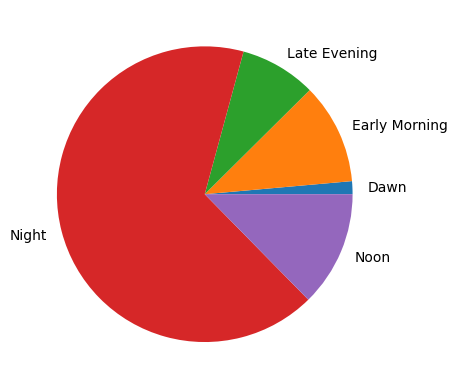

In [26]:
df[df['Cab availabilty'] == 'Available'].groupby(['TimeSlot']).size().plot(kind = 'pie')

<Axes: >

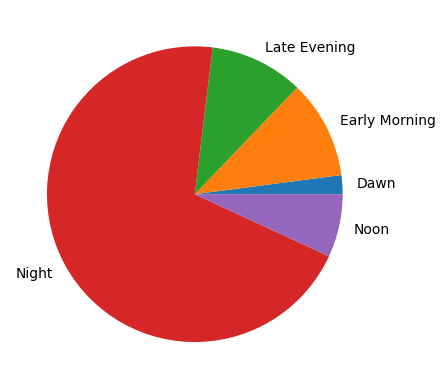

In [27]:
df[df['Cab availabilty'] != 'Available'].groupby(['TimeSlot']).size().plot(kind = 'pie')

<Axes: >

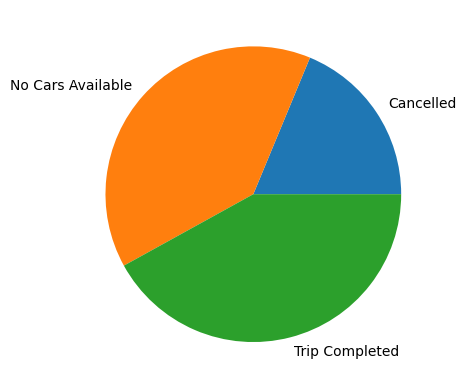

In [28]:
df.groupby(['Status']).size().plot(kind = 'pie')

Text(0.5, 1.0, 'Demand-supply overall')

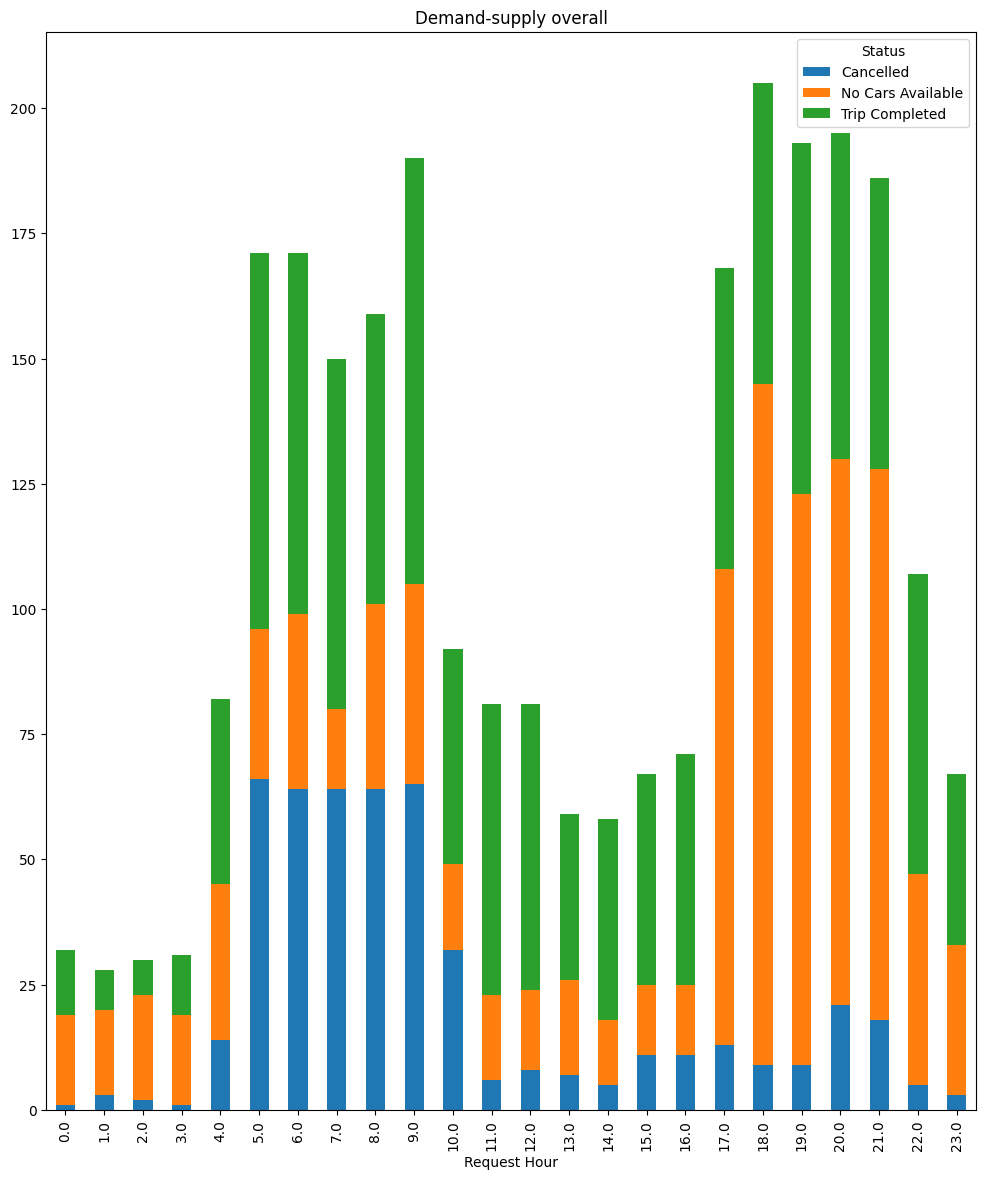

In [29]:
## Hour basis Demand - Supply

df.groupby(['Request Hour', 'Status']).size().unstack().plot(kind = 'bar', figsize = [12,14], stacked = True)
plt.title('Demand-supply overall')

Text(0.5, 1.0, 'Demand-supply from Airport to city')

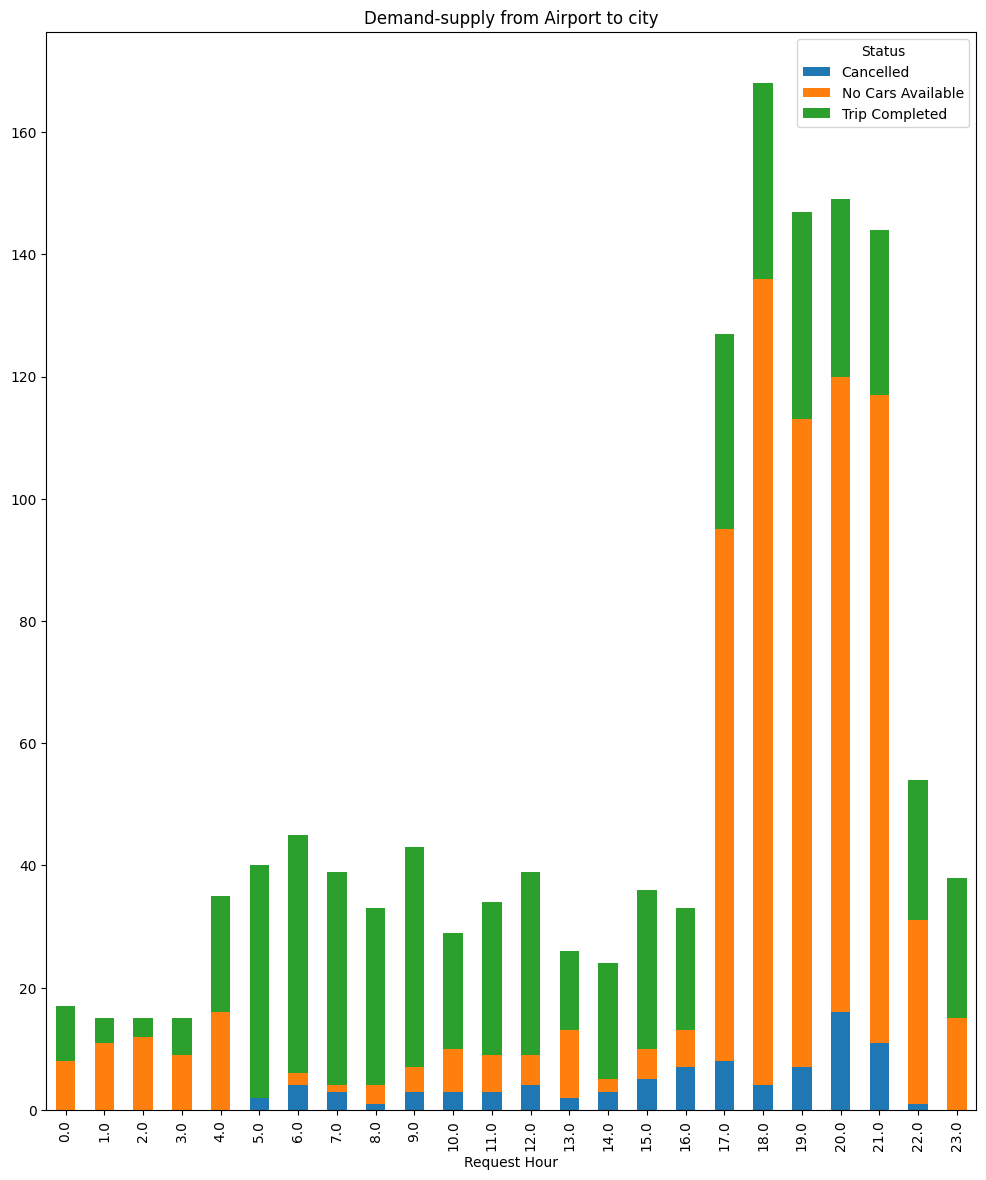

In [30]:
## Hour basis Demand - Supply -from Airport

df[df['Pickup point']=='Airport'].groupby(['Request Hour', 'Status']).size().unstack().plot(kind = 'bar', figsize = [12,14], stacked = True)
plt.title('Demand-supply from Airport to city')

Text(0.5, 1.0, 'Time slot of highest gap')

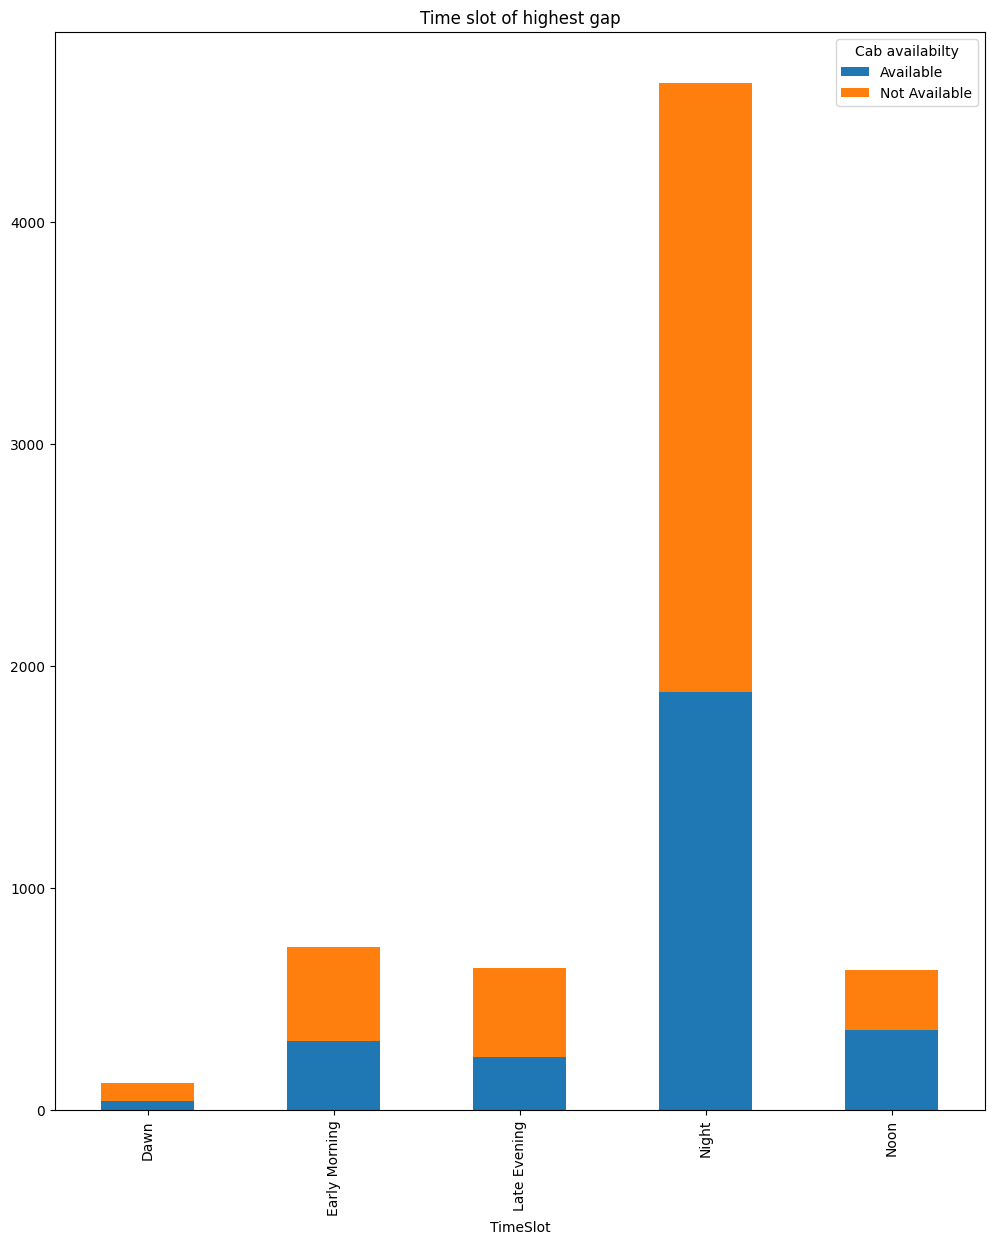

In [31]:
df.groupby(['TimeSlot', 'Cab availabilty']).size().unstack().plot(kind = 'bar', figsize = [12,14], stacked = True)
plt.title('Time slot of highest gap')

In [32]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Request Hour,TimeSlot,Cab availabilty
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00,11.0,Noon,Available
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00,17.0,Late Evening,Available
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00,9.0,Noon,Available
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00,21.0,Night,Available
4,3112,City,1.0,Trip Completed,NaT,NaT,NaN,Night,Available


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   object        
 2   Driver id          6745 non-null   object        
 3   Status             6745 non-null   object        
 4   Request timestamp  2674 non-null   datetime64[ns]
 5   Drop timestamp     1150 non-null   datetime64[ns]
 6   Request Hour       2674 non-null   float64       
 7   TimeSlot           6745 non-null   object        
 8   Cab availabilty    6745 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(5)
memory usage: 474.4+ KB
